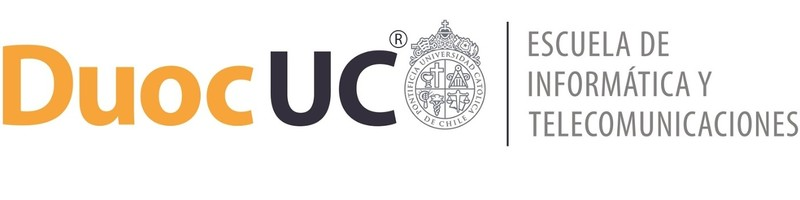

# Informe Técnico - Evaluacion 1 Mineria de Datos
# nombres: Patricio Gonzalez Rodrigo Riveros
# Seccion: 001D

# Paso 1 Importar librerias

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Paso 2 Cargar el Dataset

In [ ]:
# Configuración para ver todas las columnas
pd.set_option('display.max_columns', None)
# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)
#pd.set_option('display.max_colwidth', None)

In [ ]:
#cargar los datos
df = pd.read_csv("reels_attention_span_dataset_12000.csv", low_memory= False)
df.head()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels


In [ ]:
df.tail()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform
11995,11996,27,4.14,6.29,7.71,4.96,3.00,97.38,High,TikTok
11996,11997,42,4.07,3.27,4.20,1.02,3.30,40.79,High,Instagram Reels
11997,11998,25,0.82,3.19,6.16,7.59,1.30,41.71,Low,Instagram Reels
11998,11999,39,1.70,3.65,7.15,8.90,1.92,71.05,High,TikTok
11999,12000,33,5.79,10.91,4.35,5.36,3.65,91.36,High,TikTok


# Paso 3 Revisar los tipos de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  12000 non-null  int64  
 1   age                      12000 non-null  int64  
 2   reels_watch_time_hours   12000 non-null  float64
 3   daily_screen_time_hours  12000 non-null  float64
 4   sleep_hours              12000 non-null  float64
 5   attention_span_score     12000 non-null  float64
 6   focus_level              12000 non-null  float64
 7   task_completion_rate     12000 non-null  float64
 8   stress_level             12000 non-null  object 
 9   platform                 12000 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 937.6+ KB


In [ ]:
df.shape

(12000, 10)

# Buscamos algun tipo de nulo

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
reels_watch_time_hours,0
daily_screen_time_hours,0
sleep_hours,0
attention_span_score,0
focus_level,0
task_completion_rate,0
stress_level,0
platform,0


# al no tener nulos omitimos la limpieza de los nulos

# Explicacion de el dataset y su contenido:
El dataset reels_attention_span_dataset_12000.csv es un conjunto de datos diseñado para estudiar el impacto del consumo de videos cortos (Reels, TikTok, Shorts) en diversas métricas de bienestar y productividad de los usuarios

# Mapeo de Datos

# Clasificacion de Variables
Categorico Nominal: Categorías sin un orden o jerarquía específica.

Ejemplo: platform (Instagram Reels, TikTok, YouTube Shorts). No existe un orden lógico que diga que una plataforma es "mayor" o "menor" que otra.

Categorico Ordinal: Categorías que siguen un orden lógico o escala.

Ejemplo: stress_level. Posee una escala de intensidad clara: Low (Bajo) < Medium (Medio) < High (Alto).

Numerico Discreto: Valores que surgen de un conteo y no admiten decimales en este contexto.

Ejemplo: user_id (Identificador único de cada sujeto) y age (Edad expresada en años cumplidos).

Numerico Continuo: Valores que resultan de una medición y pueden tener decimales.

Ejemplos: * reels_watch_time_hours: Tiempo dedicado a reels (ej. 1.5 horas).

daily_screen_time_hours: Tiempo total de pantalla.

sleep_hours: Horas de sueño medidas con precisión.

attention_span_score: Puntaje obtenido en pruebas de atención.

focus_level: Nivel de enfoque medido.

task_completion_rate: Tasa de finalización (usualmente un porcentaje entre 0 y 100).


user_id: Numérico Discreto (Identificador único).

age: Numérico Discreto (Edad en años enteros).

reels_watch_time_hours: Numérico Continuo (Horas con decimales).

daily_screen_time_hours: Numérico Continuo (Horas con decimales).

sleep_hours: Numérico Continuo (Horas con decimales).

attention_span_score: Numérico Continuo (Puntaje de medición).

focus_level: Numérico Continuo (Nivel medido).

task_completion_rate: Numérico Continuo (Porcentaje o tasa).

stress_level: Categórico Ordinal (Tiene un orden lógico: Low < Medium < High).

platform: Categórico Nominal (Categorías sin un orden jerárquico: TikTok, Instagram, YouTube).

# Estadistica descriptiva a las variables numericas

In [ ]:
df.describe().round()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate
count,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0
mean,6000.0,30.0,3.0,7.0,6.0,5.0,6.0,70.0
std,3464.0,9.0,2.0,3.0,1.0,3.0,3.0,17.0
min,1.0,15.0,0.0,2.0,4.0,1.0,1.0,40.0
25%,3001.0,22.0,2.0,5.0,5.0,3.0,3.0,55.0
50%,6000.0,30.0,3.0,7.0,6.0,5.0,6.0,70.0
75%,9000.0,37.0,5.0,9.0,8.0,8.0,8.0,85.0
max,12000.0,44.0,6.0,12.0,9.0,10.0,10.0,100.0


### Aplicación de OneHotEncoding
Utilizaremos `sklearn` para transformar la variable nominal `platform` en múltiples columnas binarias.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# 1. Instanciar el codificador
ohe = OneHotEncoder(sparse_output=False)

# 2. Ajustar y transformar la columna 'platform'
platform_encoded = ohe.fit_transform(df[['platform']])

# 3. Crear un DataFrame con las nuevas columnas
platform_df = pd.DataFrame(
    platform_encoded,
    columns=ohe.get_feature_names_out(['platform']),
    index=df.index
)

# 4. Concatenar con el DataFrame original y ver resultado
df_final = pd.concat([df, platform_df], axis=1)

print("Nuevas columnas creadas por el Encoder:")
display(df_final.head())

Nuevas columnas creadas por el Encoder:


,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform,platform_Instagram Reels,platform_TikTok,platform_YouTube Shorts
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok,0.0,1.0,0.0
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok,0.0,1.0,0.0
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok,0.0,1.0,0.0
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels,1.0,0.0,0.0
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels,1.0,0.0,0.0




### Mapeo de Stress Level: Low=1, Medium=2, High=3
Usamos un mapeo manual porque `stress_level` es una variable Ordinal (tiene orden)



In [ ]:
# Mapeo de Stress Level: Low=1, Medium=2, High=3
# Usamos un mapeo manual porque 'stress_level' es una variable Ordinal (tiene orden)
mapeo_estres = {'Low': 1, 'Medium': 2, 'High': 3}
df['stress_level_num'] = df['stress_level'].map(mapeo_estres)

df.head()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform,stress_level_num
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok,2
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok,3
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok,1
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels,1
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels,1


con este mapeo lo que hacemos es que la columna stress level le cambiamos los valores para que asi pase de etiquetas cualitativas a valores numericos para que asi pueda sacar estadisticas y para futuro aplicarle modelos de correlacion

# Analisis de Correlacion





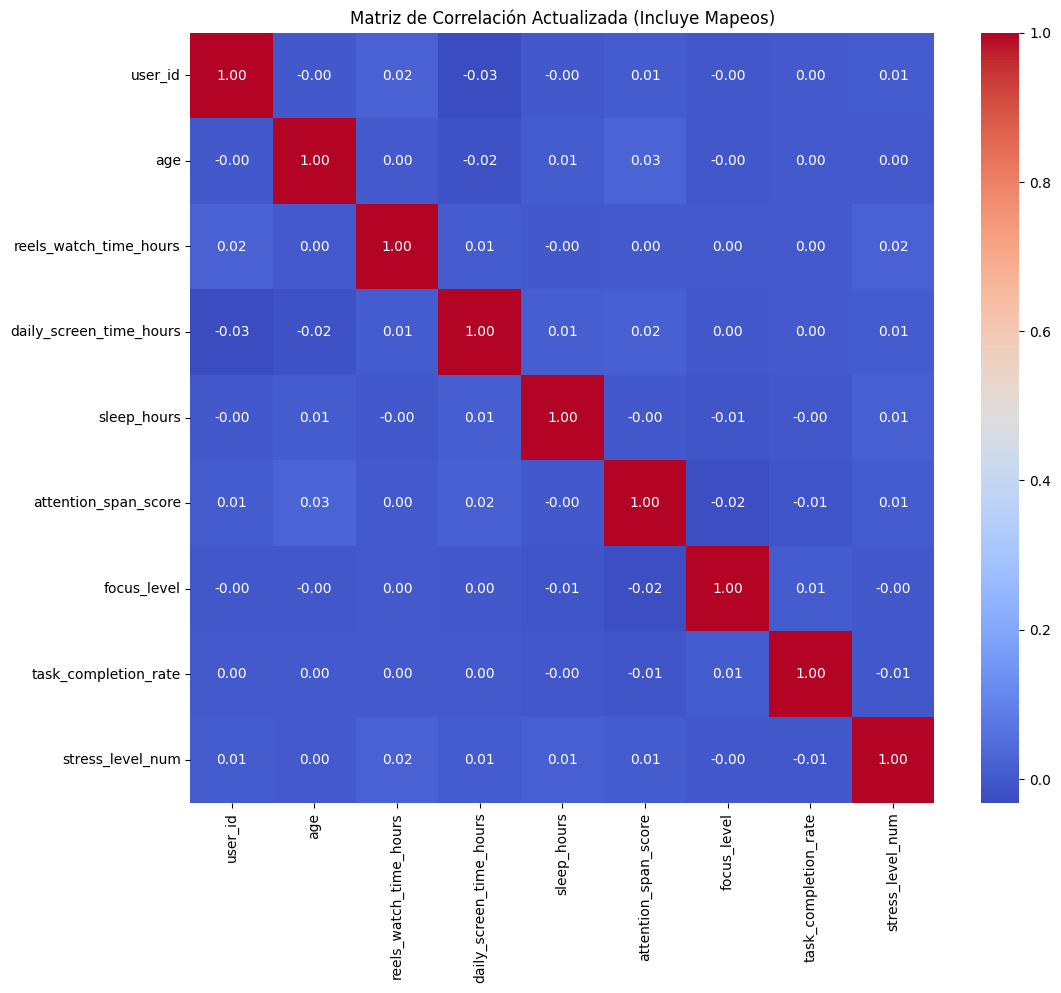

In [ ]:
# Seleccionamos todas las columnas que ahora son numéricas (incluyendo los mapeos)
corr_df = df.select_dtypes(include=[np.number]).corr()

# Creamos el mapa de calor (Heatmap) actualizado
plt.figure(figsize=(12, 10))
sb.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación Actualizada (Incluye Mapeos)")
plt.show()

# Explicacion del Matriz de Calor
En este gráfico de correlación, buscamos valores cercanos a 1 o -1. Por ejemplo, si vemos una correlación negativa fuerte entre reels_watch_time_hours y attention_span_score, significa que a medida que aumenta el tiempo viendo videos, la capacidad de atención del usuario tiende a disminuir.

# Pregunta: ¿Influye el tiempo de visualización de Reels en la calidad del sueño?

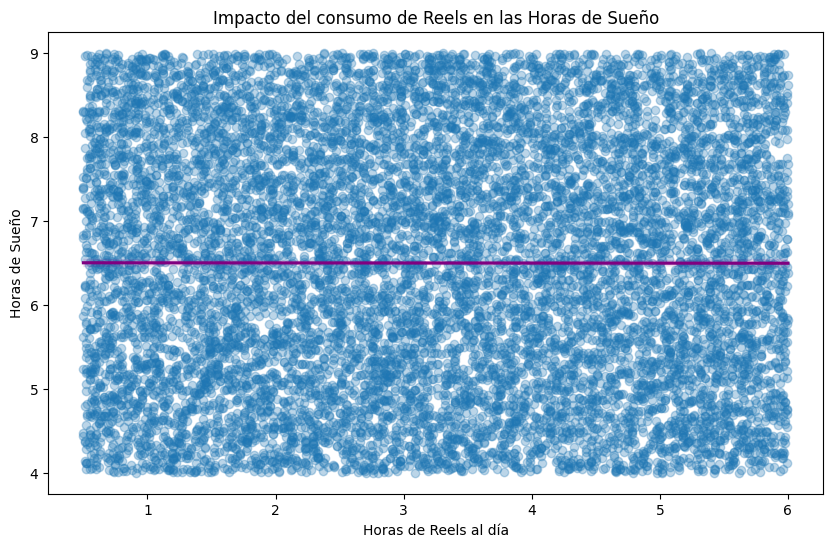

El coeficiente de correlación de Pearson es: -0.0011


In [ ]:
# Graficamos la relación
plt.figure(figsize=(10, 6))
sb.regplot(data=df, x='reels_watch_time_hours', y='sleep_hours',
           scatter_kws={'alpha':0.3}, line_kws={'color':'purple'})
plt.title('Impacto del consumo de Reels en las Horas de Sueño')
plt.xlabel('Horas de Reels al día')
plt.ylabel('Horas de Sueño')
plt.show()

# Calculamos la correlación numérica para confirmar la falta de relación
correlacion = df['reels_watch_time_hours'].corr(df['sleep_hours'])
print(f"El coeficiente de correlación de Pearson es: {correlacion:.4f}")

# Explicacion
Al analizar la relación entre reels_watch_time_hours  y sleep_hours , observamos que la línea de regresión es horizontal. Esto indica una ausencia de correlación lineal significativa entre ambas variables en este conjunto de datos específico.
Esto sugiere que, para los usuarios de esta muestra, el tiempo que pasan viendo videos cortos no es el factor determinante que define cuántas horas duermen. Existen usuarios que ven muchos Reels y duermen 8 horas, así como usuarios que ven pocos y duermen solo 4.

# Pregunta 2: ¿Cuál es la plataforma donde los usuarios reportan mayor nivel de estrés?

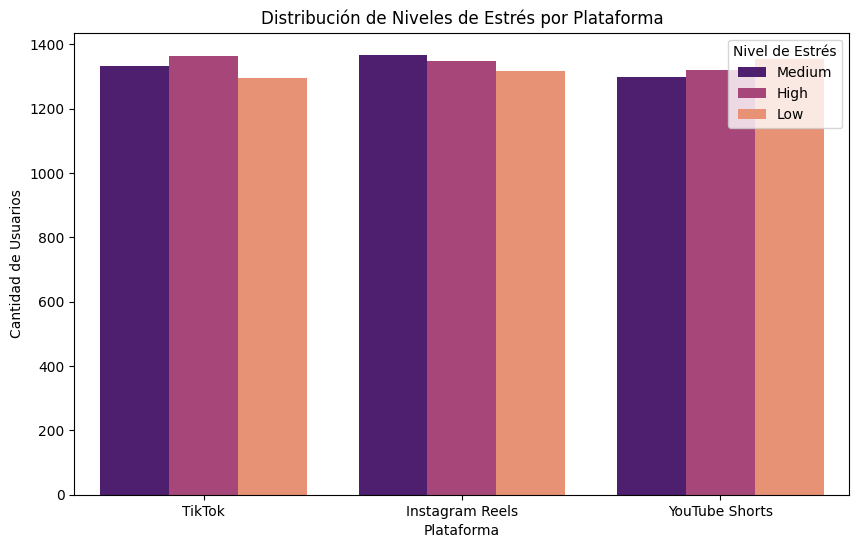

In [ ]:
plt.figure(figsize=(10, 6))
sb.countplot(data=df, x='platform', hue='stress_level', palette='magma')
plt.title('Distribución de Niveles de Estrés por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Nivel de Estrés')
plt.show()

# Explicacion de el Grafico
Al comparar las plataformas, observamos que no hay una 'red social del estrés' dominante. La distribución de los niveles de estrés es bastante equilibrada entre Instagram, TikTok y YouTube. Esto sugiere que el impacto emocional en los usuarios es similar independientemente de la interfaz o el algoritmo específico de la plataforma de videos cortos.

Un punto relevante es que la mayoría de los usuarios se concentran en niveles de estrés Bajo y Medio. Esto podría interpretarse de dos formas: o el consumo de estos contenidos actúa como un distractor que mantiene el estrés controlado, o simplemente la muestra de 12,000 personas no presenta una patología de estrés agudo derivada directamente del uso de estas aplicaciones.

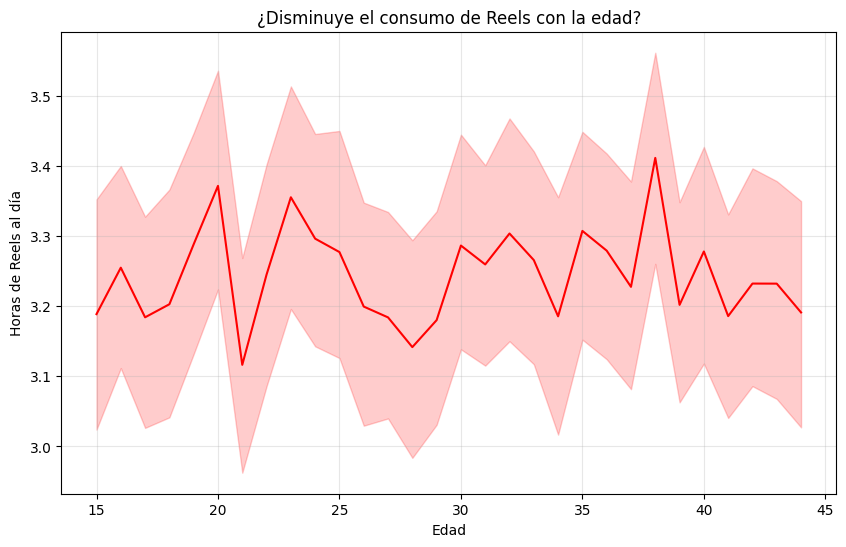

In [ ]:
plt.figure(figsize=(10, 6))
sb.lineplot(data=df, x='age', y='reels_watch_time_hours', color='red')
plt.title('¿Disminuye el consumo de Reels con la edad?')
plt.xlabel('Edad')
plt.ylabel('Horas de Reels al día')
plt.grid(True, alpha=0.3)
plt.show()

### Análisis: Edad vs. Tiempo de Visualización de Reels

Al observar el gráfico de líneas, podemos identificar la tendencia del consumo de contenido corto en relación con la edad de los usuarios:

1. **Tendencia General**: El gráfico muestra fluctuaciones constantes sin una caída drástica o un aumento lineal evidente. Esto sugiere que el interés por los Reels no es exclusivo de los jóvenes, sino que se mantiene presente en diversos rangos etarios dentro de la muestra.
2. **Picos de Consumo**: Existen edades específicas donde el consumo se dispara, lo que podría estar relacionado con hábitos de uso en momentos de transición (estudiantes vs. trabajadores).
3. **Estabilidad**: La falta de una pendiente pronunciada indica que factores como el algoritmo de recomendación logran retener a los usuarios independientemente de su edad.

en otras palabras se podria dar a entender que tanto la edad con el consumo de reels no tiene una relacion podrias tener 20 años y ver una pequeña cantidad de reels al dia como tambien tener 60 años y ver muchos reels al dia

# Selección de Modelos
1. **Modelo Elegido**: Para este análisis, hemos seleccionado un modelo de clasificación: el Árbol de Decisión (Decision Tree).
2. **El Objetivo**: El propósito de este modelo es clasificar y predecir el nivel_estres_codificado (Bajo, Medio, Alto) de los usuarios, basándose en sus hábitos de consumo digital (tiempo de uso de pantalla, horas de sueño, plataforma y tasa de completitud de tareas).



# Justificación Técnica

1. **Variable Objetivo**: Elegimos un modelo de clasificación porque nuestra variable a predecir (stress_level_num) es categórica ordinal discreta.

2. **Variables Predictoras**: Las variables que alimentan el modelo son una mezcla: tenemos numéricas continuas (como horas_reels_vistos y horas_sueno) y categóricas codificadas (como las variables binarias plataforma_TikTok, etc.).

3. **Porque Arbol de Deciciones**:: Estos algoritmos están diseñados matemáticamente para calcular la probabilidad de que una observación pertenezca a una clase discreta específica. Dado que ya preprocesamos y codificamos el estrés respetando su orden lógico (ahora con el mapeo de Low=1, Medium=2, High=3), el Árbol de Decisión capturará perfectamente estos umbrales para hacer sus divisiones.

# Análisis de Resultados

1. **Métricas de Evaluación**:Para evaluar la calidad predictiva de nuestro árbol de decisión, utilizamos la métrica de Exactitud (Accuracy) y la Matriz de Confusión.

In [ ]:
# Mapeo y Definición de Variables
mapeo_estres = {'Low': 1, 'Medium': 2, 'High': 3}
df_final['stress_level_num'] = df_final['stress_level'].map(mapeo_estres)

# 2. Definir variables predictoras (X) y objetivo (y)
X = df_final.drop(columns=['user_id', 'stress_level', 'platform', 'stress_level_num'])
y = df_final['stress_level_num']

# Preparación Final de las Variables
Como los algoritmos de Machine Learning no pueden procesar texto, primero transformamos nuestra variable objetivo (el estrés) a números usando un mapeo manual (1, 2 y 3). Lo hicimos así porque el estrés es una variable ordinal y queríamos que el modelo entendiera esa jerarquía. Luego, definimos nuestra 'X' (variables predictoras) eliminando la columna user_id para evitar ruido estadístico, y definimos nuestra 'y' (lo que queremos predecir).

In [ ]:
# División de Datos ---
from sklearn.model_selection import train_test_split

# 3. Dividir los datos (Entrenamiento y Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# División de los Datos
No podemos evaluar al modelo con los mismos datos que usó para aprender, porque
eso sería como darle las respuestas del examen por adelantado. Por eso, dividimos nuestros datos: reservamos un 67% para entrenar y un 33% completamente nuevo y oculto para probar al modelo más adelante.

In [ ]:
# Entrenamiento del Árbol de Decisión ---
from sklearn.tree import DecisionTreeClassifier

# 4. Configurar y Entrenar el Árbol de Decisión
arbol = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
arbol.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

# Configuración y Entrenamiento del Modelo
Para configurar nuestro modelo, utilizamos dos hiperparámetros clave. Primero, el criterio de 'entropía', para que el algoritmo busque la división que reduzca el desorden de los datos y Segundo limitamos la profundidad máxima a 3 niveles (max_depth=3) para evitar el sobreajuste y mantener el árbol lo suficientemente pequeño como para que fuera interpretable visualmente. Luego, entrenamos el algoritmo

In [ ]:
# Predicciones ---
# 5. Generar las predicciones para usarlas en los reportes posteriores
y_pred = arbol.predict(X_test)

# Generación de Predicciones
Finalmente, utilizamos la función predict sobre nuestro conjunto de prueba (el 33% que habíamos ocultado). El modelo generó sus predicciones basándose en las reglas que aprendió, y estas predicciones son las que compararemos con la realidad para generar nuestra matriz de confusión y el reporte de clasificación.

In [ ]:
# REPORTE DE CLASIFICACIÓN
from sklearn.metrics import classification_report

print("Reporte de Clasificación del Modelo:\n")
# Usamos las predicciones (y_pred) y los datos reales (y_test) que ya calculaste arriba
print(classification_report(y_test, y_pred, target_names=["Bajo (1)", "Medio (2)", "Alto (3)"]))

Reporte de Clasificación del Modelo:

              precision    recall  f1-score   support

    Bajo (1)       0.33      0.23      0.27      1284
   Medio (2)       0.34      0.74      0.46      1317
    Alto (3)       0.30      0.04      0.07      1359

    accuracy                           0.33      3960
   macro avg       0.32      0.34      0.27      3960
weighted avg       0.32      0.33      0.27      3960



**La Exactitud General**:Nuestro modelo obtuvo una exactitud (Accuracy) del 33%. Como estamos clasificando tres categorías distintas (Bajo, Medio, Alto), este número equivale estadísticamente a una predicción aleatoria

Si observamos el reporte, el modelo desarrolló un sesgo hacia la categoría 'Medio (2)', logrando identificar correctamente el 74% de estos casos, lo que se refleja en un recall de 0.74.
Sin embargo, el algoritmo sufre un colapso predictivo al intentar detectar el estrés 'Alto (3)', con apenas un 4% de acierto (recall de 0.04).

**Conclusión Parcial**: Esto demuestra que los perfiles de los usuarios se solapan demasiado entre sí. No existen reglas matemáticas claras basadas puramente en el uso de pantallas que logren separar a una persona con estrés alto de una con estrés bajo o medio.

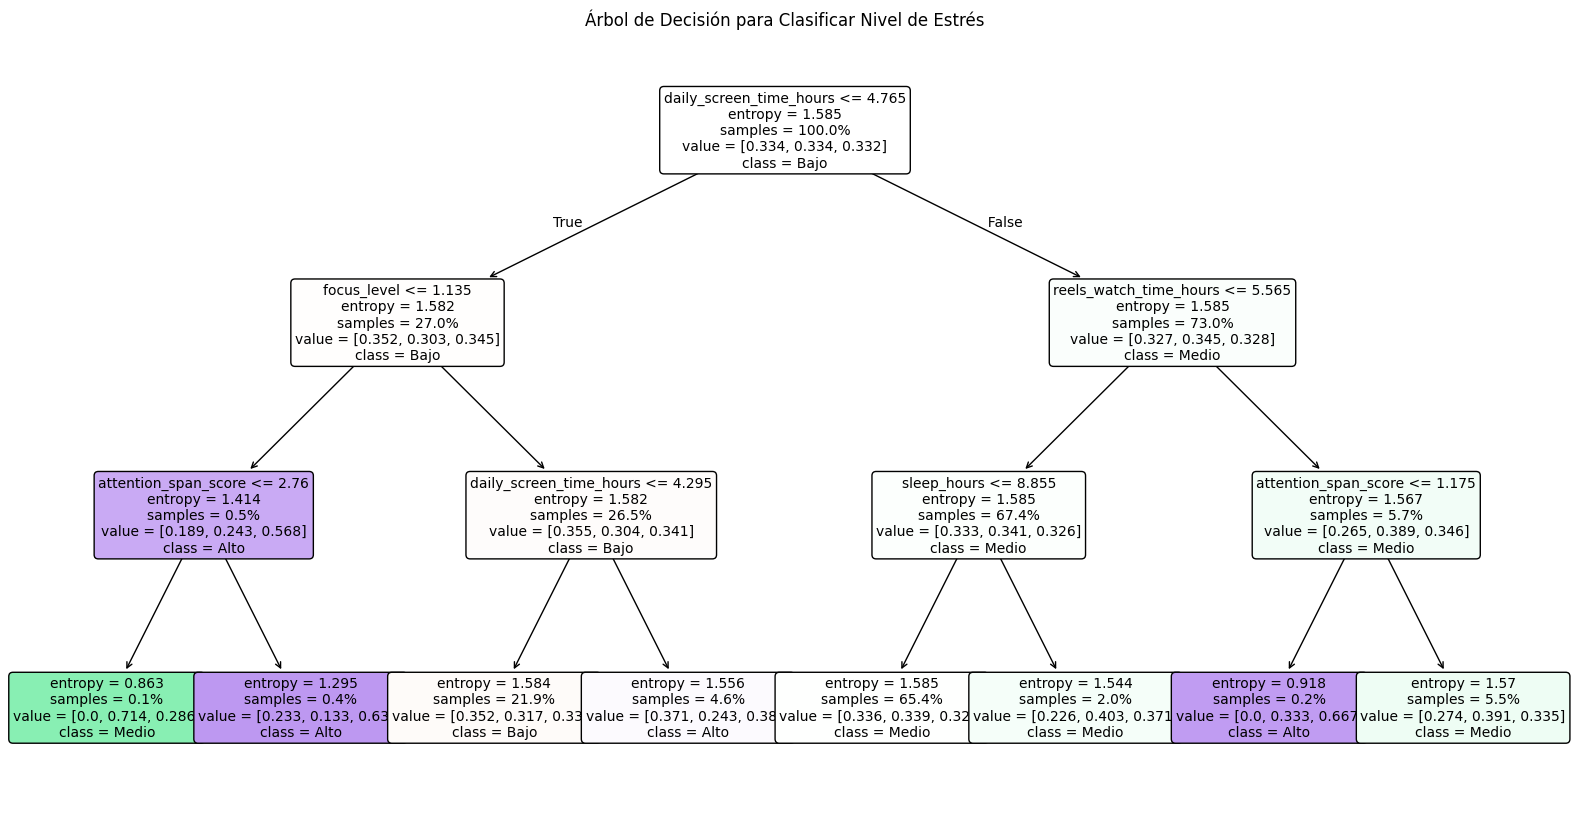

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 6. Visualizar el Árbol (Caja Blanca)
plt.figure(figsize=(20, 10))
plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=["Bajo", "Medio", "Alto"],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10
)
plt.title("Árbol de Decisión para Clasificar Nivel de Estrés")
plt.show()

Al visualizar nuestro Árbol de Decisión, podemos entender exactamente por qué la exactitud general se mantuvo en el 33%. El algoritmo intenta segmentar a los usuarios, haciendo un primer corte en quienes pasan más o menos de 4.765 horas diarias en pantalla.


El Problema de la Entropía: A pesar de estas divisiones, los nodos resultantes mantienen una entropía altísima, cercana a 1.58. Para tres categorías, el nivel máximo de desorden matemático es 1.585. Esto significa que el árbol divide y divide a la gente, pero los grupos resultantes siguen igual de mezclados.


Los Valores (Value): Si observamos los vectores de valores (values) en las hojas finales, vemos que las tres clases de estrés siguen repartidas en tercios casi perfectos, por ejemplo: [0.355, 0.304, 0.341].


Conclusión Parcial: El árbol nunca logra aislar un grupo que sea, por ejemplo, 90% estrés 'Alto'. Esta es la prueba visual de que no existen umbrales claros en el consumo digital que aíslen a los usuarios.

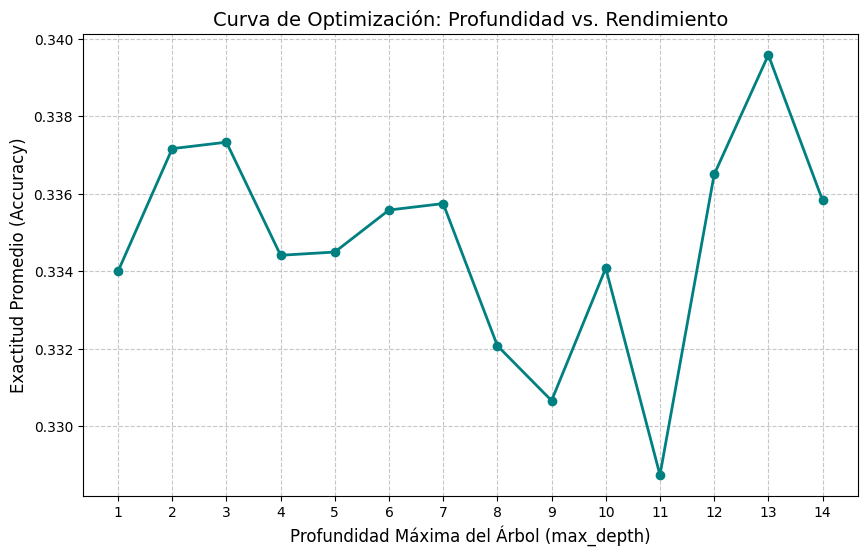

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 1. Definir variables (asegurando quitar el ID y las columnas de texto)
X = df_final.drop(columns=['user_id', 'stress_level', 'platform', 'stress_level_num'])
y = df_final['stress_level_num']

# 2. Configurar el rango de profundidades a probar (del 1 al 14)
profundidades = range(1, 15)
rendimientos = []

# 3. Iterar para entrenar un modelo por cada profundidad
for profundidad in profundidades:
    arbol_actual = DecisionTreeClassifier(max_depth=profundidad, criterion="entropy", random_state=42)
    # cross_val_score entrena y prueba el modelo 5 veces (cv=5) para dar un promedio más confiable
    exactitud = cross_val_score(arbol_actual, X, y, cv=5, scoring="accuracy").mean()
    rendimientos.append(exactitud)

# 4. Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(profundidades, rendimientos, marker='o', linestyle='-', color='teal', linewidth=2)
plt.xlabel("Profundidad Máxima del Árbol (max_depth)", fontsize=12)
plt.ylabel("Exactitud Promedio (Accuracy)", fontsize=12)
plt.title("Curva de Optimización: Profundidad vs. Rendimiento", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(profundidades)
plt.show()

A simple vista, el gráfico parece tener subidas y bajadas drásticas. Sin embargo, si miramos atentamente el eje vertical, la escala es diminuta: el punto más bajo está en 32.8% y el pico más alto apenas roza el 34%.


Para asegurarnos de que el bajo rendimiento no fuera un error nuestro de configuración, realizamos esta optimización probando profundidades del 1 al 14. Al realizar la optimización de hiperparámetros, comprobamos que el rendimiento del modelo nunca supera el 34%, sin importar la profundidad del árbol.


Conclusión Final: Esto no es un fallo del algoritmo, sino un hallazgo de nuestro análisis. Las variables de consumo digital analizadas (tiempo en pantalla, plataformas, horas de sueño) simplemente no contienen la información suficiente ni la correlación necesaria para predecir el estrés humano de forma aislada. Hemos demostrado que el estrés es una variable no solo depende del tiempo de consumo de reels etc.